测试数据和训练数据分组，数据分batch

CompactBearingCNN(
  (conv_layers): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(2,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool1d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8064, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_featur

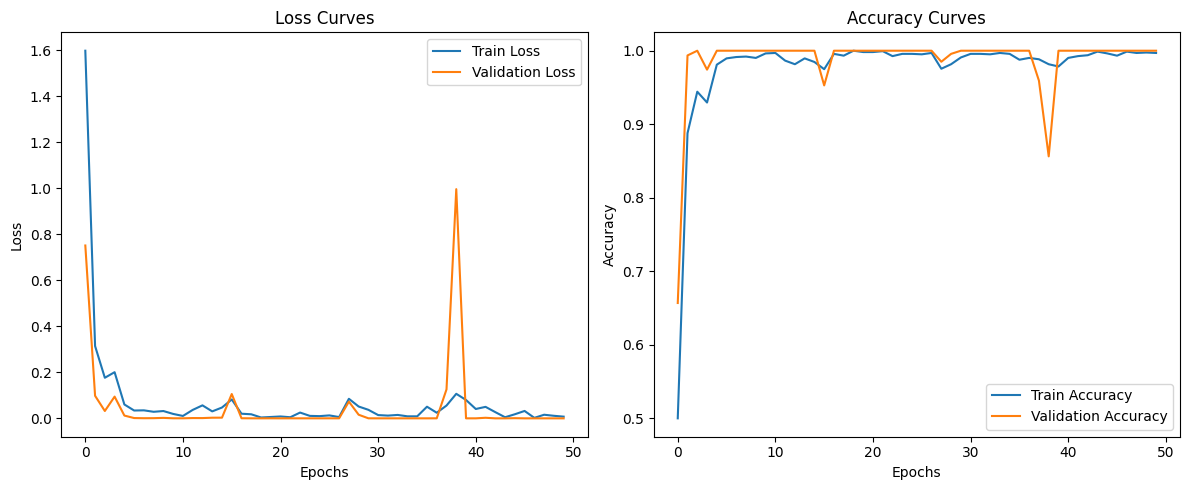

Test Accuracy: 0.9957


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from joblib import load
import matplotlib.pyplot as plt
# 超参数设置
BATCH_SIZE = 32  # 修改为32
EPOCHS = 50
LEARNING_RATE = 0.001
NUM_CLASSES = 10

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 修改后的数据加载函数
def load_data(data_path):
    df = load(data_path)
    features = df.iloc[:, :-1].values.astype(np.float32)  # 确保特征为浮点数
    labels = df.iloc[:, -1].values.astype(np.int64)       # 显式转换为整数
    
    # 转换为PyTorch Tensor
    features = torch.FloatTensor(features).unsqueeze(1)  # 形状 [n, 1, 1024]
    labels = torch.LongTensor(labels)
    
    return features, labels

# 加载数据集
train_features, train_labels = load_data('train_set')
val_features, val_labels = load_data('val_set')
test_features, test_labels = load_data('test_set')

# 创建DataLoader（自动使用新batch_size）
train_dataset = TensorDataset(train_features, train_labels)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(val_features, val_labels)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

test_dataset = TensorDataset(test_features, test_labels)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# 修改后的CNN模型
class CompactBearingCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CompactBearingCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            # 输入形状: [batch, 1, 1024]
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3),  # 输出通道减半
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2),  # 输出: [32, 255]
            
            nn.Conv1d(32, 64, kernel_size=5, padding=2),  # 输出通道减半
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2),  # 输出: [64, 127]
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),  # 输出通道减半
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2)  # 输出: [128, 63]
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(128 * 63, 256),  # 调整输入维度
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# 初始化修改后的模型
model = CompactBearingCNN(num_classes=NUM_CLASSES).to(device)
print(model)  # 打印模型结构

# 训练配置（保持不变）
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 训练和验证函数（保持不变）
def train_model(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    return total_loss/len(dataloader), acc

def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    return total_loss/len(dataloader), acc

# 在训练循环前添加记录容器
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# 训练循环（保持不变）
best_val_acc = 0.0
for epoch in range(EPOCHS):
    train_loss, train_acc = train_model(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate_model(model, val_loader, criterion)
    
    # 记录指标
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # 保存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'compact_best_model.pth')
    
    print(f'Epoch {epoch+1}/{EPOCHS}')
    print(f'Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}\n')
# 绘制训练曲线函数
def plot_training_curves(train_loss, val_loss, train_acc, val_acc):
    plt.figure(figsize=(12, 5))
    
    # 损失曲线
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='Train Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # 准确率曲线
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_curves.png')  # 保存图像
    plt.show()
# 绘制曲线
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)

# 测试修改后的模型
model.load_state_dict(torch.load('compact_best_model.pth'))
test_loss, test_acc = evaluate_model(model, test_loader, criterion)
print(f'Test Accuracy: {test_acc:.4f}')

定义 SGCN 分类网络模型

注意调整参数，
1. 可以适当增加 GCN层数 和每层神经元个数，微调学习率；
2. 增加更多的 epochs,  （注意防止过拟合）